# 2.3 starCAT for projecting gene expression programs to all plasma cells

Author: Xuezhu Sunny Wang

## Dataset 📊

- Seurat object of all plasma cells
- Gene list of gene expression programs, from the cNMF analysis of clonal plasma cells

## Steps overview 📒

- Use starCAT to infer the usage (activity) of gene expression programs
- Plot the change between paired pre and post treatment samples

In [1]:
import sys
from cnmf import cNMF
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import starCAT



In [2]:
tcat = starCAT(reference='./cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt', 
               cachedir='./query_cNMF/cache')


Using user specified reference spectra file ./cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt
No scores provided


In [3]:
tcat.ref

,PERM1,ISG15,TTLL10,TNFRSF18,TNFRSF4,TAS1R3,TMEM52,MMEL1,AL512413.1,MEGF6,...,AMELY,TBL1Y,AC064829.1,AC244213.1,AC004556.3,AC233755.2,AC233755.1,AC136616.3,AC136616.2,AC141272.1
GEP1,0.000000,0.605092,0.000000,0.000000,0.000000,0.112493,0.000000,0.000000,0.001787,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP2,0.046746,0.426410,0.000000,0.354571,0.360851,0.623126,0.449011,0.029182,0.000000,0.054676,...,0.000000,0.000000,0.000000,0.022139,0.214174,0.000000,0.230403,0.091618,0.310233,0.481726
GEP3,0.000000,0.377933,0.006809,0.508294,0.397441,0.169179,0.006413,0.000000,0.000000,0.040408,...,0.098393,0.080297,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP4,0.000000,0.002521,0.000000,1.113971,0.975821,0.000000,0.000000,0.000000,0.001403,0.022440,...,0.000000,0.000000,0.059156,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP5,0.055977,0.834073,0.052521,0.239575,0.298272,0.000000,0.384284,0.009218,0.000000,0.103687,...,0.014648,0.000000,0.000000,0.925469,0.288303,0.000000,3.531507,0.000000,0.000000,0.000000
GEP6,0.003823,0.115977,0.000000,0.124212,0.261377,0.830904,0.446456,0.004871,0.045169,0.005919,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004694,0.000000,0.000000
GEP7,0.000000,0.142833,0.000000,0.679429,0.739847,0.038123,0.000000,0.002912,0.000000,0.001585,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP8,0.000000,0.000000,0.000000,0.000000,0.000000,0.272512,0.122547,0.011927,0.000000,0.001070,...,0.044460,0.210256,0.000000,0.000000,0.161448,5.954403,0.000000,0.000000,0.000000,0.007968
GEP9,0.000000,0.649994,0.000000,0.000000,0.071790,0.000000,0.000000,0.202136,0.000000,0.136788,...,0.000000,0.000000,0.000000,0.005475,0.031971,0.000000,0.000000,0.000000,0.000000,0.000000
GEP10,0.000000,0.243783,0.000000,0.056349,0.142326,0.100253,0.000000,0.000000,0.000000,0.145105,...,0.000000,0.000000,0.000000,0.000000,0.173782,0.000000,0.000000,0.000000,0.005580,0.018929


In [4]:
adata = sc.read_h5ad("counts.h5ad")

In [5]:
# Run starCAT 
usage, _ = tcat.fit_transform(adata)


/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/starcat/starcat.py:244: UserWarning: WARNING!: query input is not an integer count matrix as expected.
            Please provide an integer count matrix unless you are sure you know what you are doing.
  warnings.warn("""WARNING!: query input is not an integer count matrix as expected.


2000 out of 2000 genes in the reference overlap with the query


In [6]:
usage.head()

,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8,GEP9,GEP10,GEP11,GEP12,GEP13
ALl14_AAACGAACAGTTGTTG-1,1.356822e-02,0.178538,0.198700,0.000860,2.450875e-02,0.001016,0.000903,0.006238,5.528831e-01,0.009377,8.626594e-06,2.470986e-03,0.010929
ALl14_AAACGAAGTATCGAGG-1,3.477405e-08,0.030206,0.135598,0.036761,2.182667e-08,0.011737,0.000002,0.001184,9.909277e-02,0.665929,1.886467e-02,2.888846e-07,0.000626
ALl14_AAACGCTCAAGTGCAG-1,5.078875e-05,0.069008,0.169955,0.000018,4.197900e-02,0.001011,0.000397,0.006825,5.220535e-01,0.146092,6.295720e-08,6.100504e-03,0.036511
ALl14_AAAGAACAGAGGCTGT-1,3.890765e-07,0.102221,0.109052,0.033791,3.313666e-03,0.000001,0.222891,0.017171,2.292119e-01,0.079816,1.732428e-02,2.769686e-07,0.185206
ALl14_AAAGGATAGATGCAGC-1,3.451473e-07,0.380463,0.148958,0.286097,3.077109e-03,0.172029,0.000003,0.002438,8.509454e-09,0.000453,2.327552e-10,1.298624e-05,0.006468


In [7]:
adata

AnnData object with n_obs × n_vars = 232300 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'

In [8]:
# Merge usages and scores with cell metadata
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)


In [9]:
adata

AnnData object with n_obs × n_vars = 232300 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'GEP9', 'GEP10', 'GEP11', 'GEP12', 'GEP13'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'

First we plot the discrete features output by starCAT

As well as continuous scores

And we can output the continuous usages of all of the cGEPs

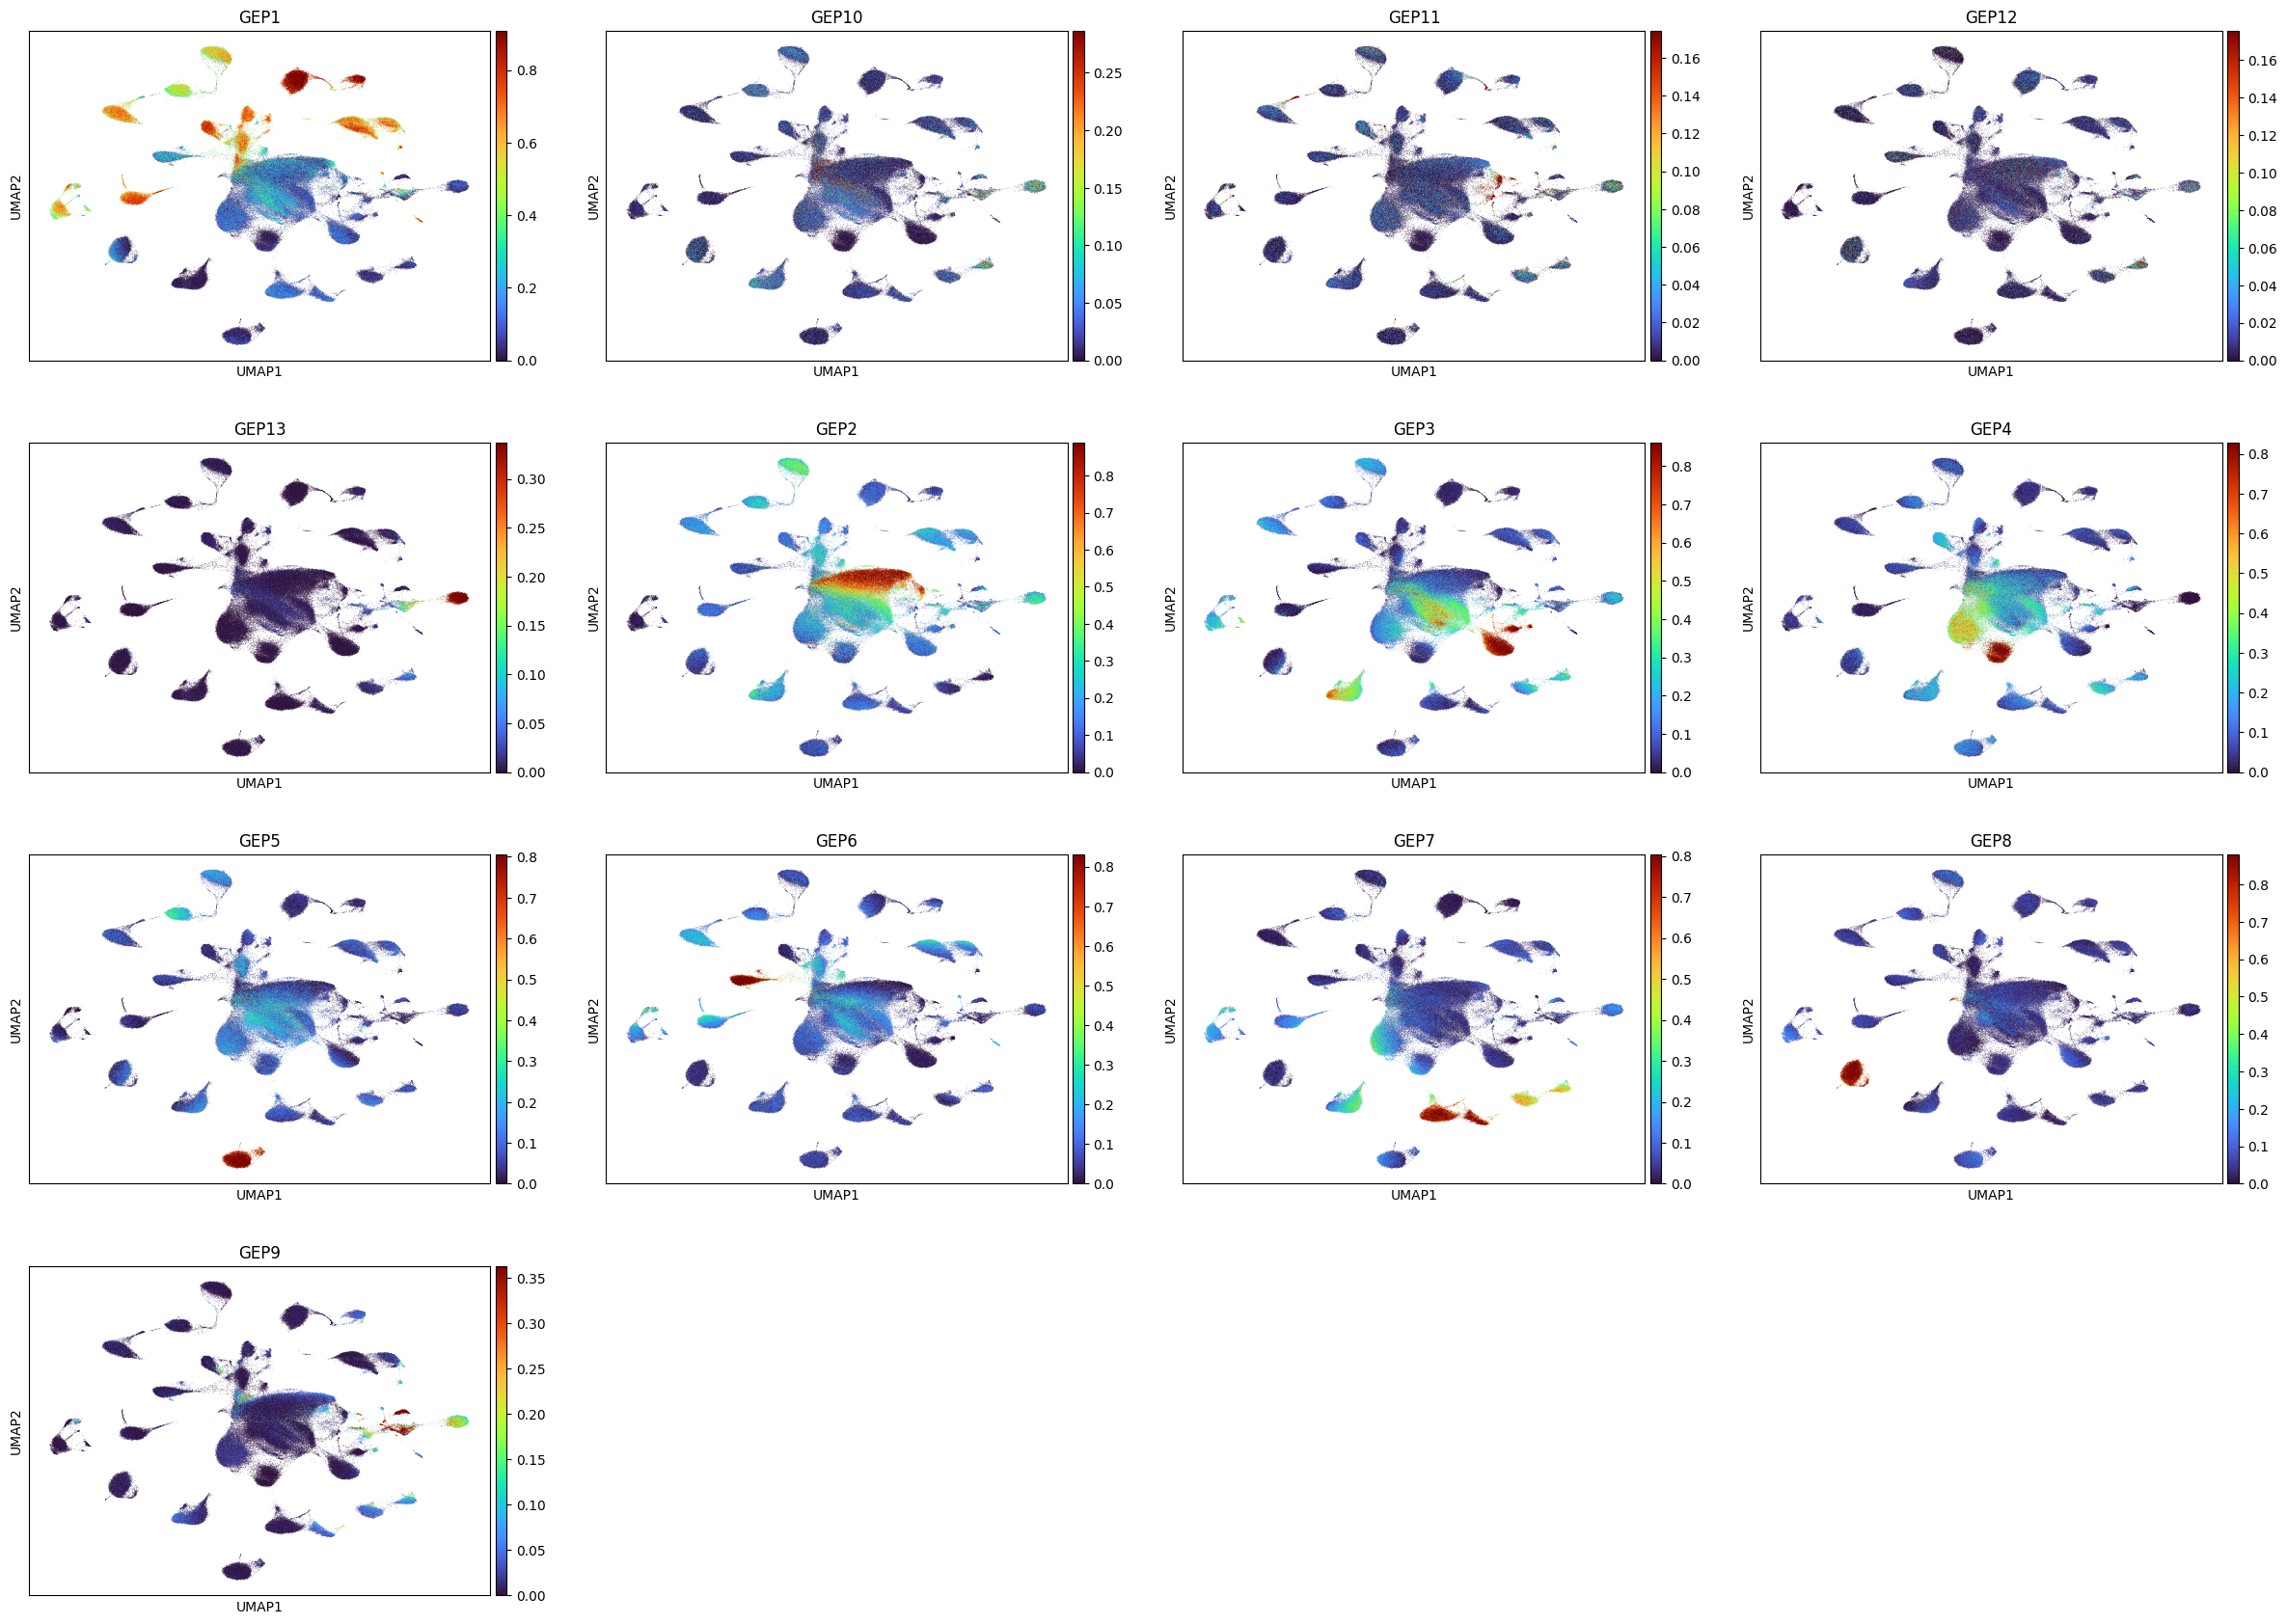

In [10]:
sc.pl.umap(adata, color=sorted(usage.columns), ncols=4, vmin=0, vmax='p99',color_map="turbo")

In [11]:
import numpy as np
import pandas as pd

# --- choose the CNMF usage columns of interest ---
use_cols = ["GEP1", "GEP2", "GEP4", "GEP6","GEP11", "GEP3","GEP7"]
present = [c for c in use_cols if c in adata.obs.columns]
if len(present) == 0:
    raise ValueError("None of the required CNMF columns are present in adata.obs")

# Subset and ensure numeric
U = adata.obs[present].apply(pd.to_numeric, errors="coerce")

# Map column name -> status number
status_map = {"GEP1":1, "GEP2":2,"GEP4":4,"GEP6":6, "GEP11":11,"GEP3":3, "GEP7":7}

# Row-wise argmax to pick the dominant component
argmax_idx = U.values.argmax(axis=1)  # returns positional index among `present`
chosen_cols = [present[i] if np.isfinite(i) else np.nan for i in argmax_idx]

# Convert chosen column names to status numbers; NaN if all four are NaN
status = []
confidence = []
for i, row in U.iterrows():
    vals = row.values.astype(float)
    if np.all(~np.isfinite(vals)):
        status.append(np.nan)
        confidence.append(np.nan)
        continue
    s = np.nansum(vals)
    m = np.nanmax(vals)
    # chosen column:
    j = np.nanargmax(vals)
    status.append(status_map[present[j]])
    # confidence = max / sum (guard zero/NaN)
    conf = (m / s) if (np.isfinite(m) and np.isfinite(s) and s > 0) else np.nan
    confidence.append(conf)

adata.obs["cnmf_status"] = pd.Series(status, index=U.index).astype("Float64")
adata.obs["cnmf_status_confidence"] = pd.Series(confidence, index=U.index).astype("Float64")

# Optional: mark low-confidence as unclassified (commented out)
# THRESH = 0.4
# mask_low = adata.obs["cnmf_status_confidence"].fillna(0) < THRESH
# adata.obs.loc[mask_low, "cnmf_status"] = pd.NA

# Make a categorical for nicer plotting (keeps numeric labels as strings)
adata.obs["cnmf_status_cat"] = (
    adata.obs["cnmf_status"]
    .astype("Int64")
    .astype(str)
    .replace({"<NA>": "NA"})
    .astype("category")
)

print(
    "Assigned cnmf_status to "
    f"{adata.obs['cnmf_status'].notna().sum()} / {adata.n_obs} cells.\n"
    "Value counts:\n",
    adata.obs["cnmf_status_cat"].value_counts(dropna=False)
)


Assigned cnmf_status to 232291 / 232300 cells.
Value counts:
 cnmf_status_cat
1     77169
2     50107
3     39012
4     31579
7     22184
6     10688
11     1552
NA        9
Name: count, dtype: int64


/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cnmf_status_cat'}, xlabel='UMAP1', ylabel='UMAP2'>

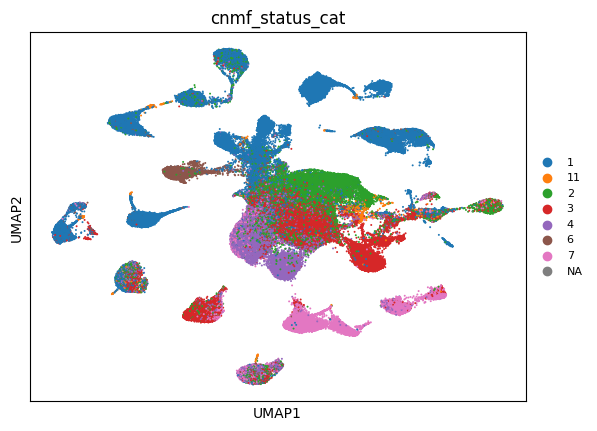

In [12]:

# --- Figure layout (2 panels side by side)
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

sc.pl.umap(
    adata,
    color=["cnmf_status_cat"],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)


In [13]:
usage_norm = adata.obs[use_cols]

In [14]:
usage_norm.to_csv("plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv", index=True)

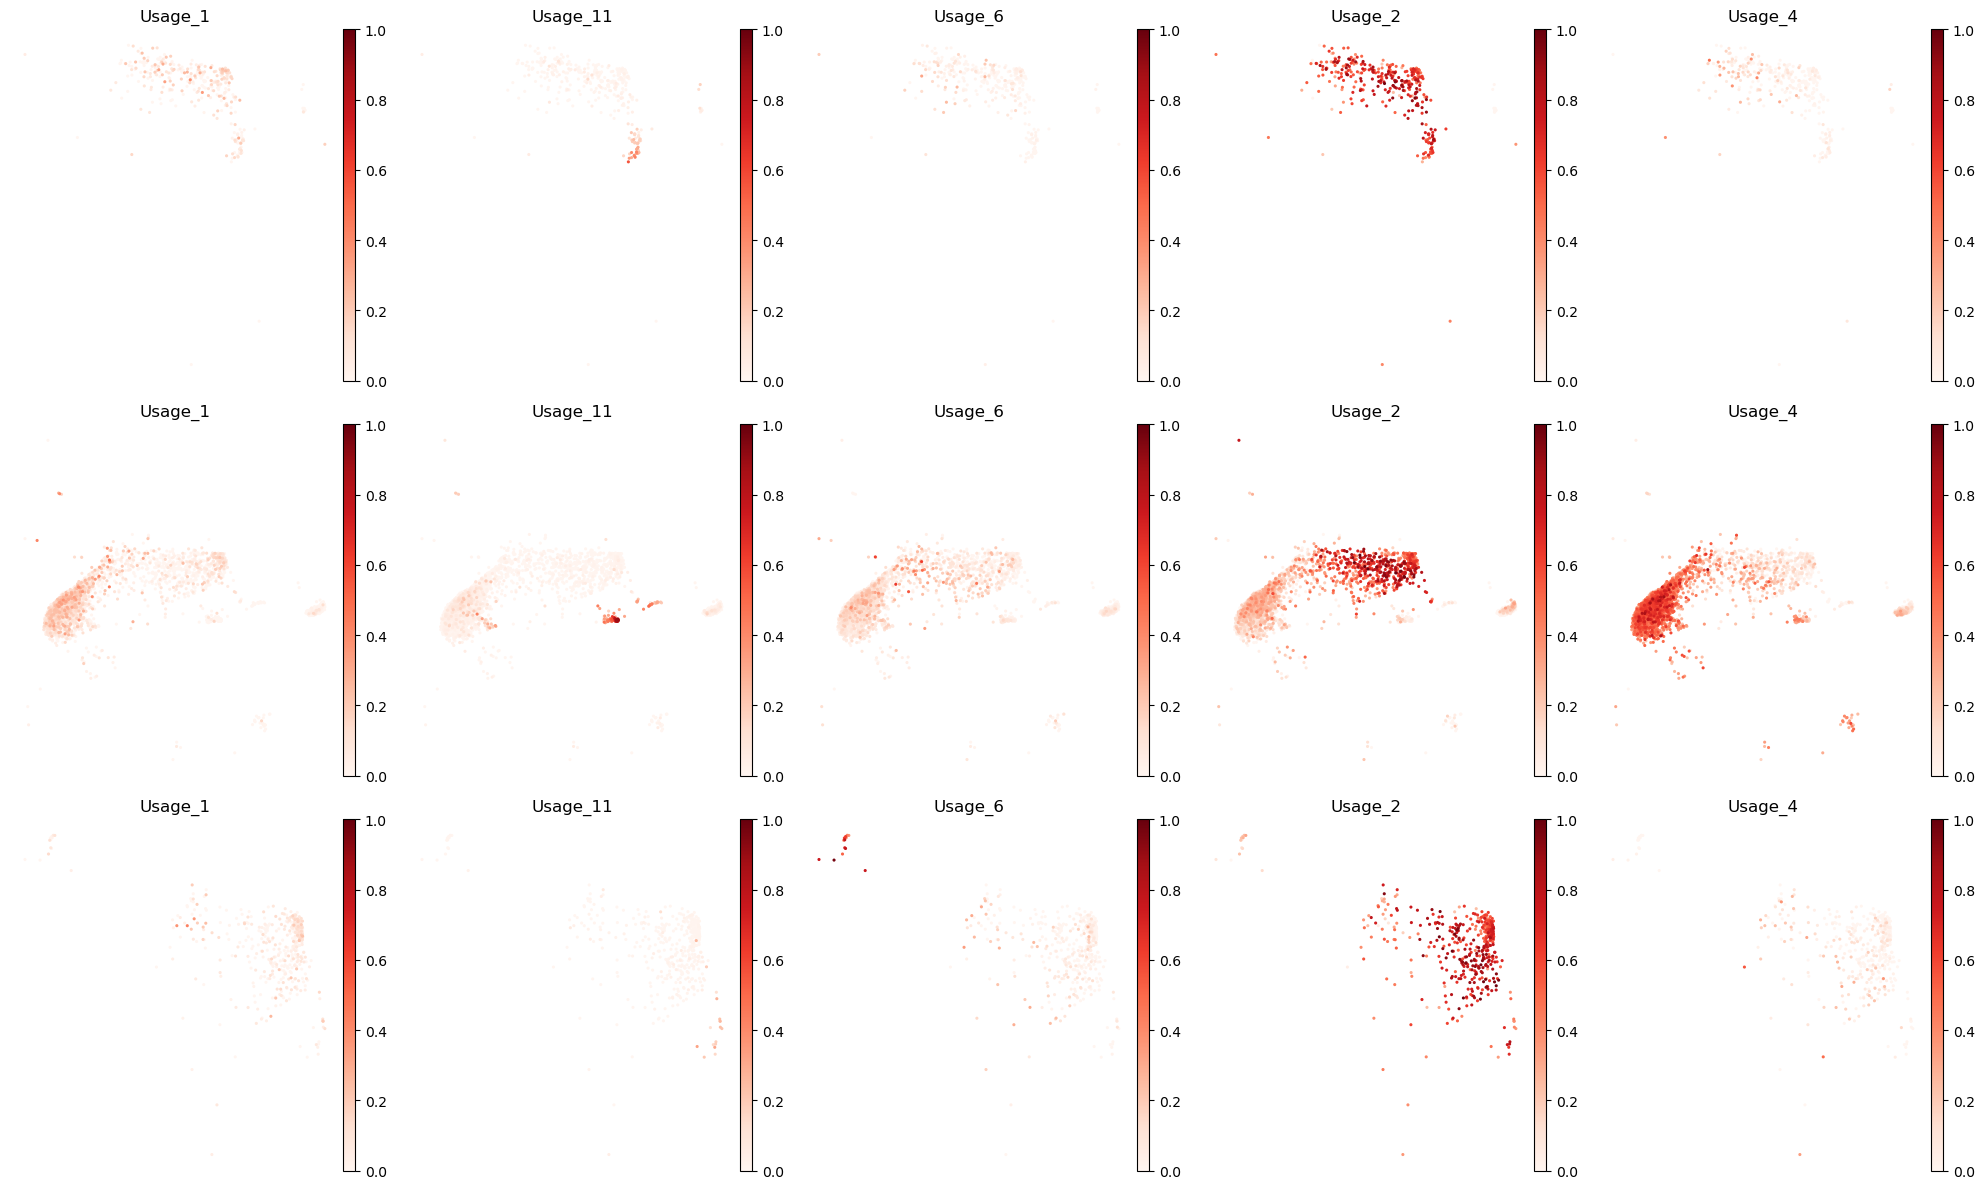

In [8]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if ("post" in s)]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()


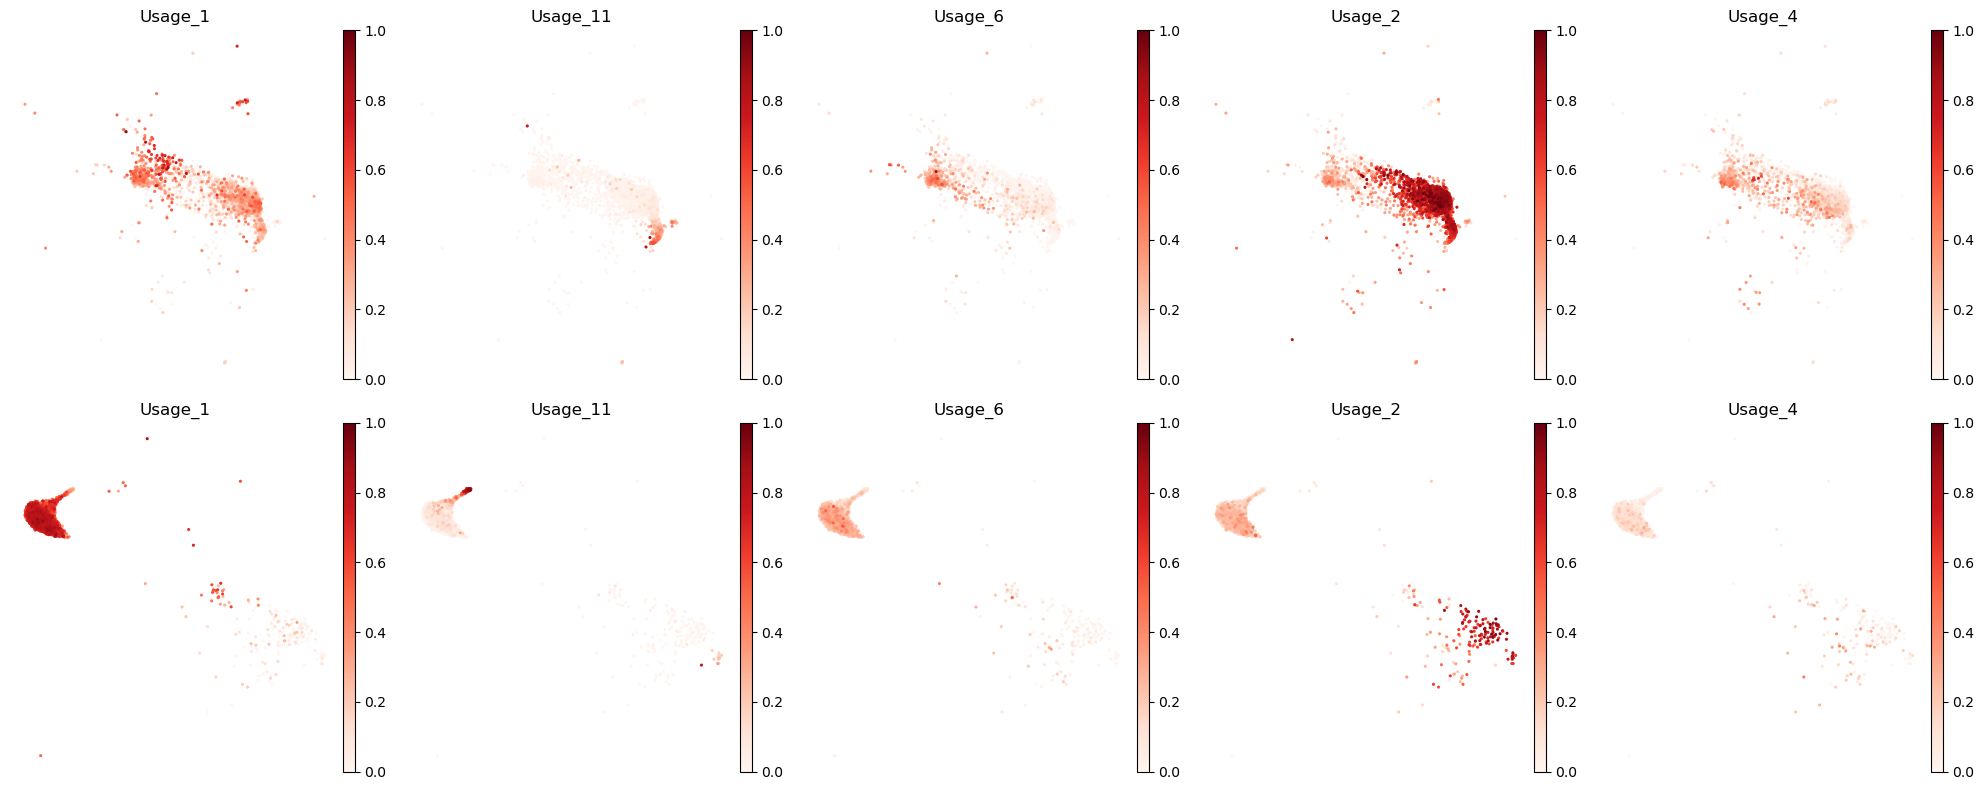

In [9]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if  ("refrac" in s)]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()


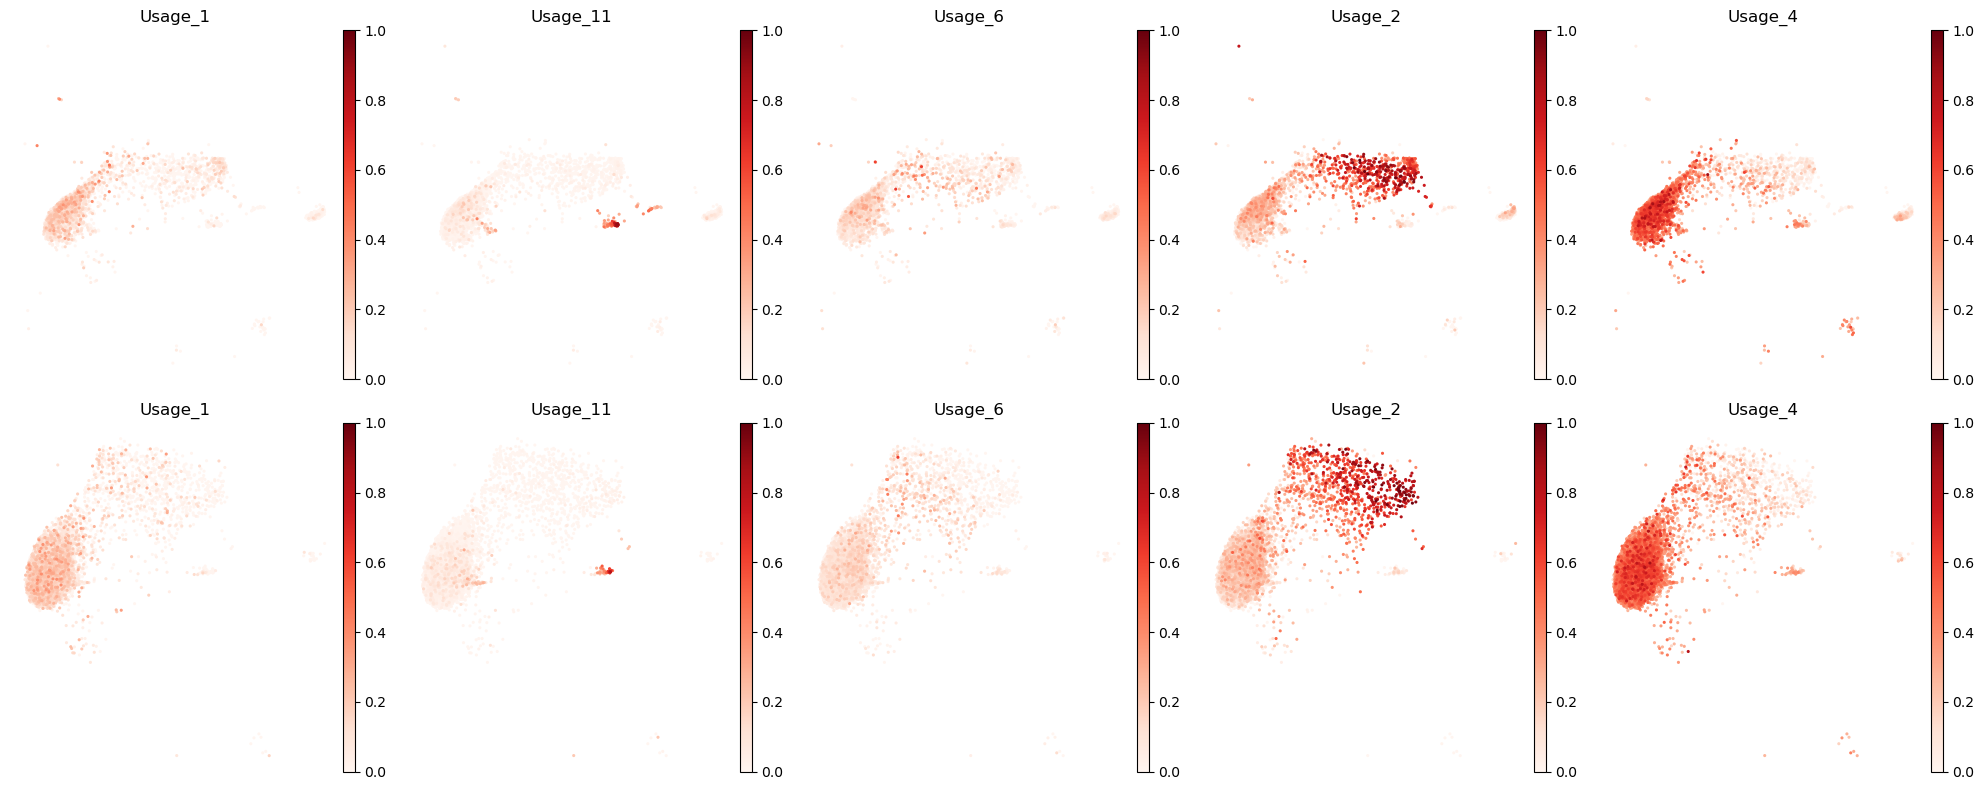

In [10]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if ("ALl5" in s) ]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()


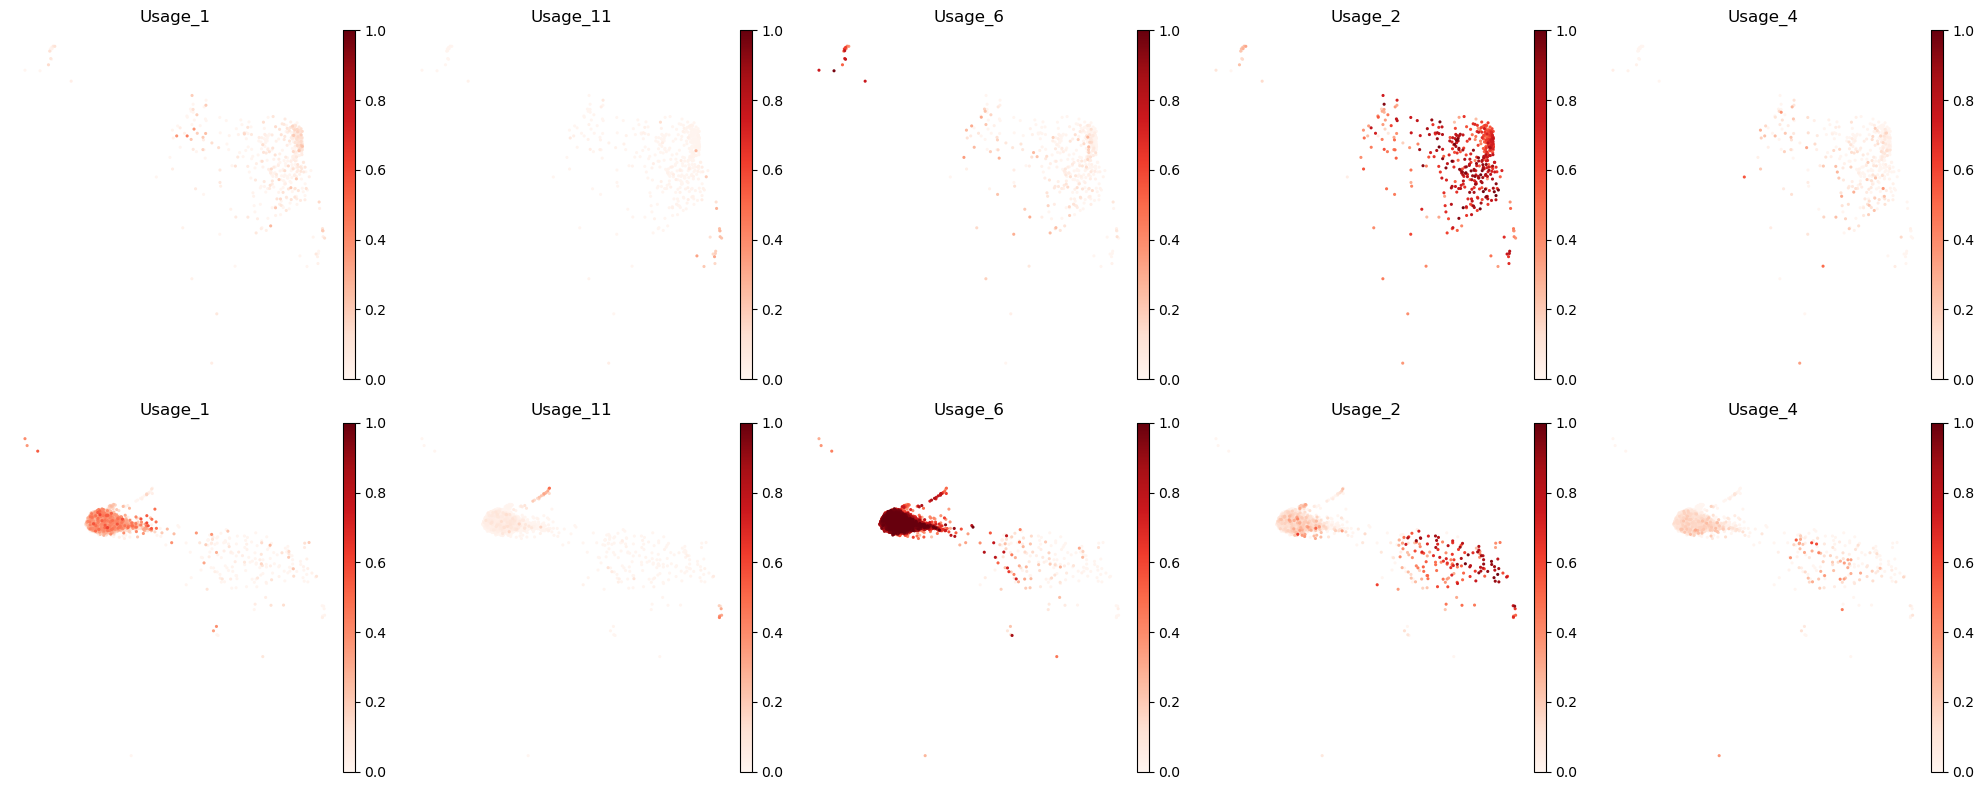

In [11]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if ("ALk3" in s)]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()


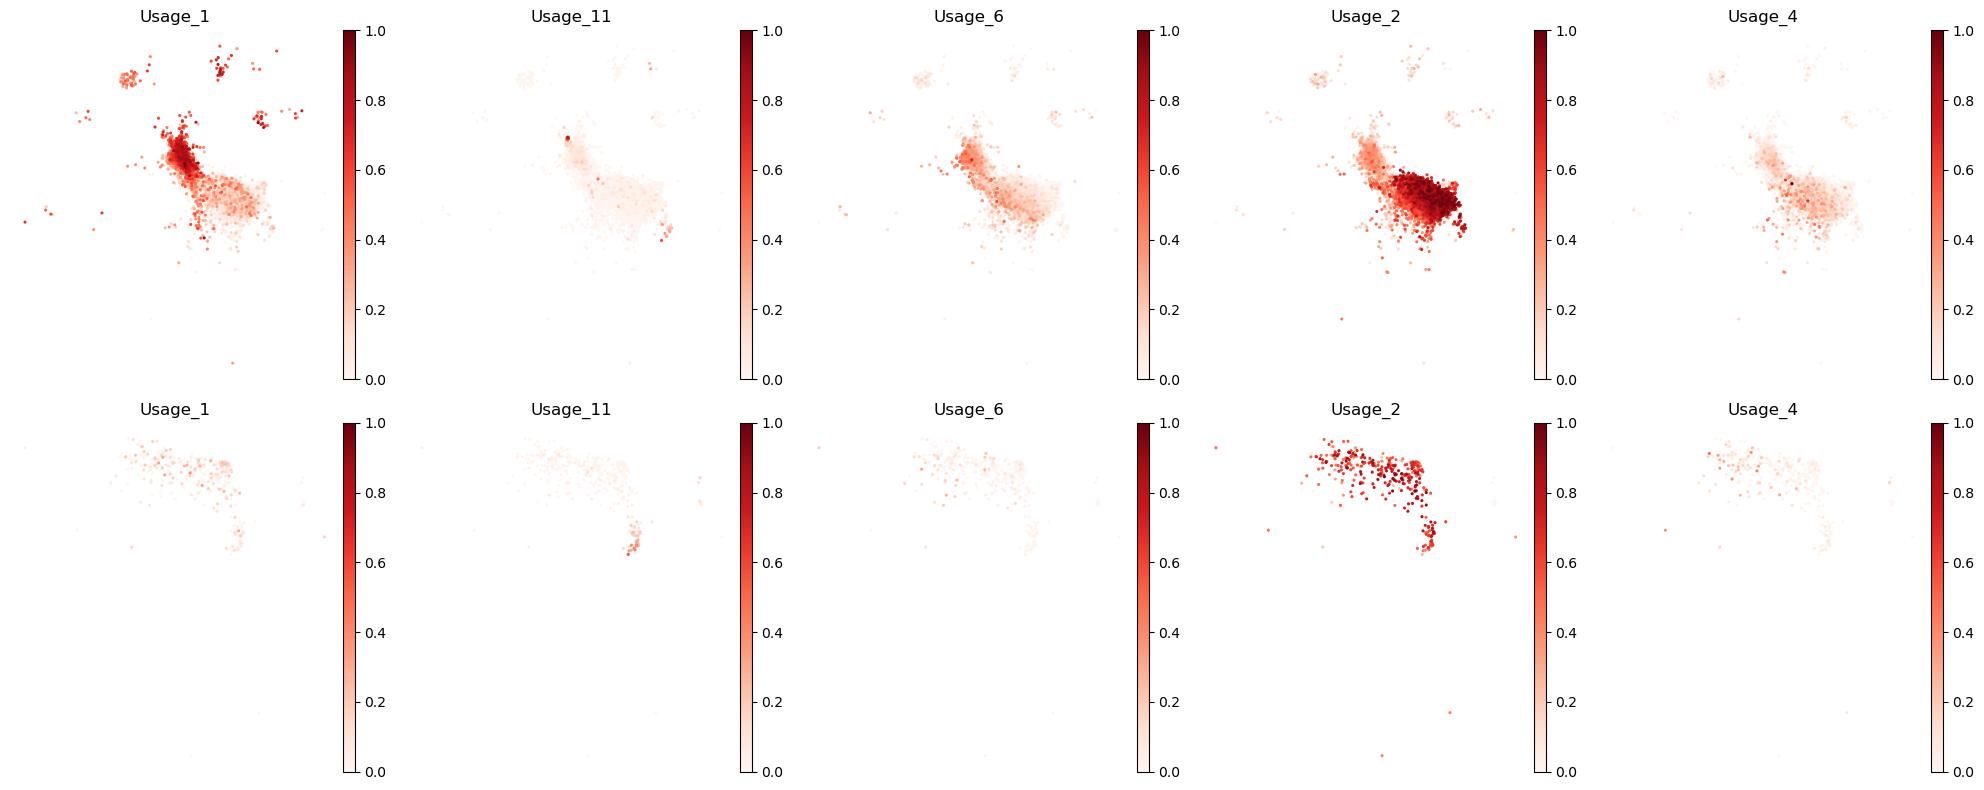

In [12]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if  ("ALl9" in s)]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()
